In [12]:
import cv2
import numpy as np

def gaussian_blur(img, ksize=5, sigma=1.4):
    """Apply Gaussian filter manually."""
    ax = np.linspace(-(ksize - 1) / 2., (ksize - 1) / 2., ksize)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel = kernel / np.sum(kernel)
    return cv2.filter2D(img, -1, kernel)

In [13]:
def sobel_gradients(img):
    """Compute gradients using Sobel filters."""
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

    Ix = cv2.filter2D(img.astype(np.float32), -1, Kx)
    Iy = cv2.filter2D(img.astype(np.float32), -1, Ky)

    magnitude = np.sqrt(Ix**2 + Iy**2)
    direction = np.arctan2(Iy, Ix)
    return magnitude, direction

In [14]:
def non_maximum_suppression(magnitude, direction):
    """Thin edges by suppressing non-maximum pixels."""
    M, N = magnitude.shape
    Z = np.zeros((M, N), dtype=np.float32)
    angle = direction * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1, M-1):
        for j in range(1, N-1):
            q = 255
            r = 255

            # angle 0
            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = magnitude[i, j+1]
                r = magnitude[i, j-1]
            # angle 45
            elif (22.5 <= angle[i, j] < 67.5):
                q = magnitude[i+1, j-1]
                r = magnitude[i-1, j+1]
            # angle 90
            elif (67.5 <= angle[i, j] < 112.5):
                q = magnitude[i+1, j]
                r = magnitude[i-1, j]
            # angle 135
            elif (112.5 <= angle[i, j] < 157.5):
                q = magnitude[i-1, j-1]
                r = magnitude[i+1, j+1]

            if (magnitude[i, j] >= q) and (magnitude[i, j] >= r):
                Z[i, j] = magnitude[i, j]
            else:
                Z[i, j] = 0
    return Z

In [15]:
def double_threshold(img, low_ratio=0.05, high_ratio=0.15):
    """Apply double thresholding to classify edges."""
    high = img.max() * high_ratio
    low = high * low_ratio

    res = np.zeros_like(img, dtype=np.uint8)

    strong = np.uint8(255)
    weak = np.uint8(50)

    strong_i, strong_j = np.where(img >= high)
    weak_i, weak_j = np.where((img <= high) & (img >= low))

    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak
    return res, weak, strong

In [16]:
def hysteresis(img, weak=50, strong=255):
    """Edge tracking by hysteresis."""
    M, N = img.shape
    for i in range(1, M-1):
        for j in range(1, N-1):
            if img[i, j] == weak:
                if ((img[i+1, j-1] == strong) or (img[i+1, j] == strong) or (img[i+1, j+1] == strong)
                    or (img[i, j-1] == strong) or (img[i, j+1] == strong)
                    or (img[i-1, j-1] == strong) or (img[i-1, j] == strong) or (img[i-1, j+1] == strong)):
                    img[i, j] = strong
                else:
                    img[i, j] = 0
    return img

In [17]:
def canny_edge(img, sigma=1.4, low_ratio=0.05, high_ratio=0.15):
    """Full Canny pipeline."""
    blurred = gaussian_blur(img, 5, sigma)
    mag, direction = sobel_gradients(blurred)
    nms = non_maximum_suppression(mag, direction)
    dt, weak, strong = double_threshold(nms, low_ratio, high_ratio)
    edges = hysteresis(dt, weak, strong)
    return edges

In [18]:
def hough_lines(edge_img, rho_res=1, theta_res=np.pi/180, threshold=100):
    """Perform Hough Transform for lines."""
    rows, cols = edge_img.shape
    max_rho = int(np.sqrt(rows**2 + cols**2))
    rhos = np.arange(-max_rho, max_rho, rho_res)
    thetas = np.arange(0, np.pi, theta_res)

    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)

    y_idxs, x_idxs = np.nonzero(edge_img)  # edge points
    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]
        for t_idx in range(len(thetas)):
            rho = int(x * np.cos(thetas[t_idx]) + y * np.sin(thetas[t_idx]))
            rho_idx = np.argmin(np.abs(rhos - rho))
            accumulator[rho_idx, t_idx] += 1

    # Find peaks above threshold
    lines = []
    for r_idx in range(accumulator.shape[0]):
        for t_idx in range(accumulator.shape[1]):
            if accumulator[r_idx, t_idx] > threshold:
                rho = rhos[r_idx]
                theta = thetas[t_idx]
                lines.append((rho, theta))
    return lines, accumulator

In [19]:
def draw_hough_lines(img, lines):
    """Draw lines on the image."""
    output = img.copy()
    if len(output.shape) == 2:
        output = cv2.cvtColor(output, cv2.COLOR_GRAY2BGR)
    for rho, theta in lines:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(output, (x1, y1), (x2, y2), (0, 0, 255), 2)
    return output

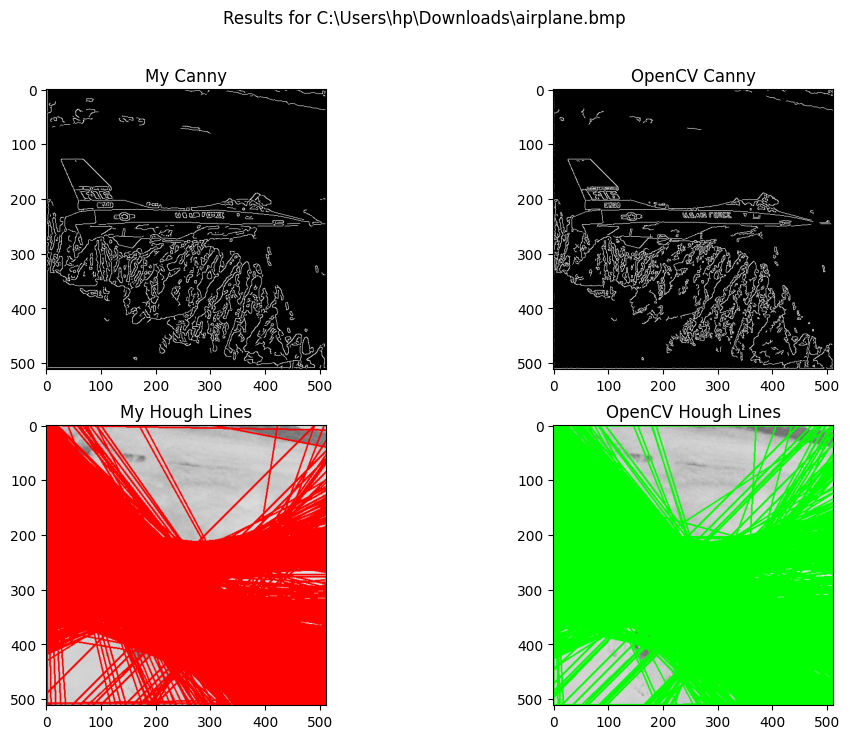

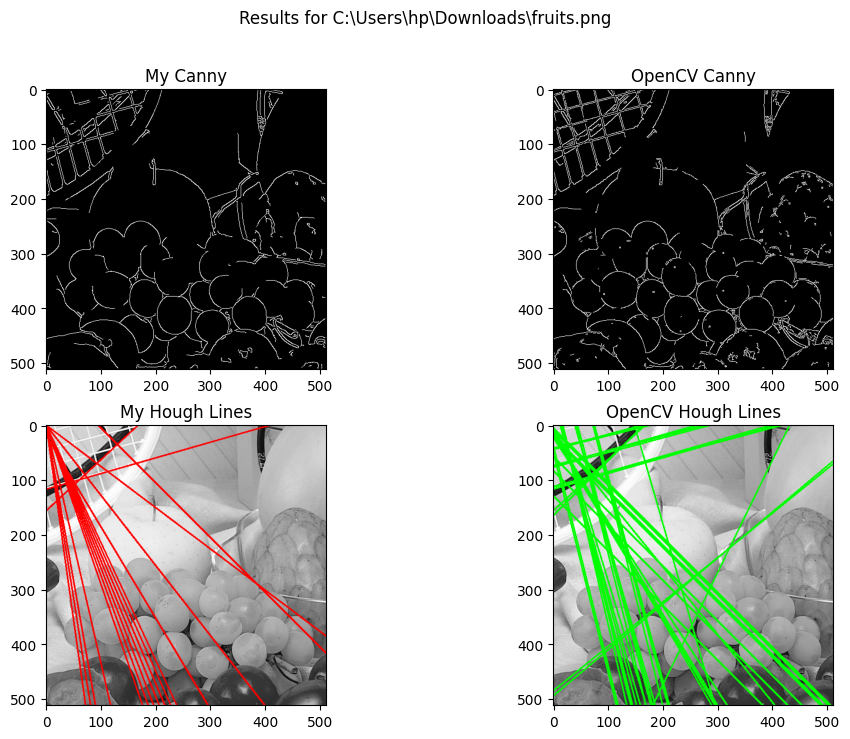

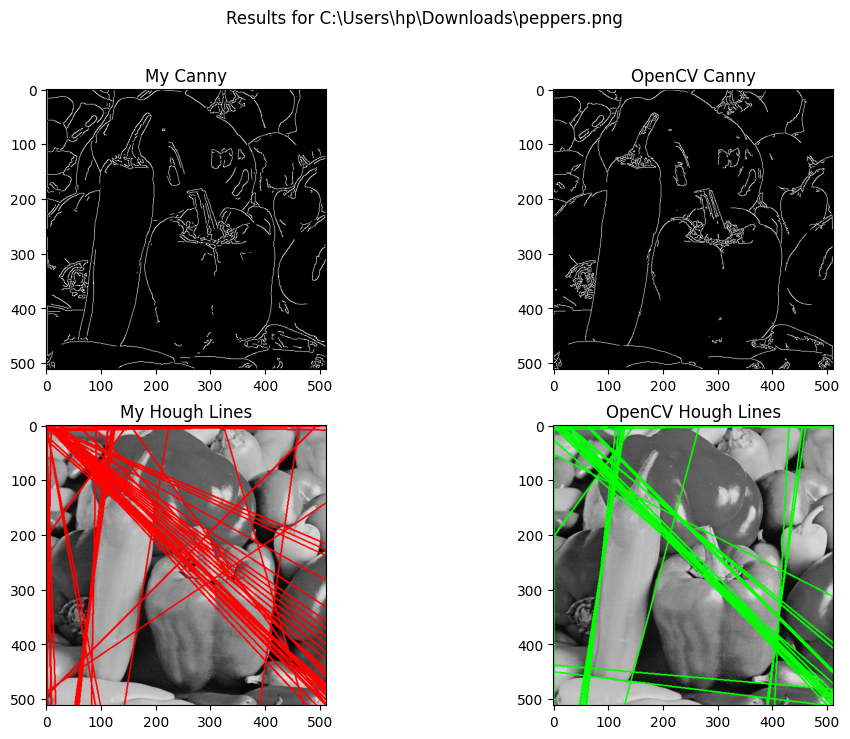

In [22]:
import matplotlib.pyplot as plt

# Load test images
images = [
    r"C:\Users\hp\Downloads\airplane.bmp",
    r"C:\Users\hp\Downloads\fruits.png",
    r"C:\Users\hp\Downloads\peppers.png"
]

for path in images:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Our Canny
    my_edges = canny_edge(img)

    # OpenCV Canny
    cv_edges = cv2.Canny(img, 100, 200)

    # Our Hough
    my_lines, acc = hough_lines(my_edges, threshold=80)
    img_hough = draw_hough_lines(img, my_lines)

    # OpenCV Hough
    lines = cv2.HoughLines(cv_edges, 1, np.pi/180, 80)
    img_cv_hough = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if lines is not None:
        for line in lines:
            rho, theta = line[0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(img_cv_hough, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Show Comparisons
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 2, 1); plt.imshow(my_edges, cmap='gray'); plt.title("My Canny")
    plt.subplot(2, 2, 2); plt.imshow(cv_edges, cmap='gray'); plt.title("OpenCV Canny")
    plt.subplot(2, 2, 3); plt.imshow(img_hough[..., ::-1]); plt.title("My Hough Lines")
    plt.subplot(2, 2, 4); plt.imshow(img_cv_hough[..., ::-1]); plt.title("OpenCV Hough Lines")
    plt.suptitle(f"Results for {path}")
    plt.show()